## Projeto em BI e Analytics
### Aluno: Carlos Graf

Este projeto investiga o impacto da Inteligência Artificial no mercado de trabalho de desenvolvimento de software. A análise parte da hipótese de que o avanço das ferramentas de IA, com a consolidação da IA generativa, está associado a mudanças na demanda por desenvolvedores, e busca evidências quantitativas para embasar essa relação.

### Etapa 0: Importações

Bibliotecas utilizadas neste notebook:
- **yfinance**: coleta de dados de mercado financeiro via Yahoo Finance
- **pandas** / **numpy**: manipulação e transformação de dados
- **scikit-learn**: modelagem preditiva (regressão linear)
- **matplotlib**: visualizações exploratórias para validação dos dados

In [128]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

### Etapa 1: Coleta

Dados que correlacionam diretamente o mercado de trabalho de desenvolvimento de software com a adoção de IA são escassos, principalmente pela dificuldade em mensurar e publicar essa relação de forma sistemática. Diante disso, a estratégia adotada foi buscar proxies quantificáveis: volume de vagas abertas, sentimento do mercado financeiro e interesse de busca da população.

As seguintes fontes foram selecionadas:

#### FRED — Software Development Job Postings on Indeed (EUA)
Índice que mede a demanda por vagas de desenvolvimento de software nos Estados Unidos, publicado pelo Federal Reserve Bank of St. Louis.
Fonte: https://fred.stlouisfed.org/series/IHLIDXUSTPSOFTDEVE

#### Stanford — The 2025 AI Index Report
Relatório institucional do Stanford HAI com dados sobre adoção, impacto econômico e percepções do mercado em relação à IA.
Fonte: https://hai.stanford.edu/ai-index/2025-ai-index-report

#### Google Trends
Volume de buscas ao longo do tempo para os termos:
- `"AI Coding"` — proxy para o interesse em ferramentas de IA para desenvolvimento
- `"Developer Job"` — proxy para a demanda percebida por vagas na área

Fonte: https://trends.google.com.br/

#### AIQ — Global X Artificial Intelligence & Technology ETF
ETF que agrega empresas de IA e tecnologia, coletado via API do Yahoo Finance. Utilizado como proxy do desempenho do setor de inteligência artificial no mercado financeiro.

In [147]:
# Coletar dados do índice AIQ via API
df = yf.download("AIQ", start="2018-05-11", interval="1mo") # AIQ launch date
df.reset_index(inplace=True)

# Salva o arquivo
df.to_csv("data/market/aiq.csv", index=False)

[*********************100%***********************]  1 of 1 completed


### Etapa 2: Preparação e Seleção dos Dados

Antes da limpeza, cada fonte foi avaliada quanto à sua aderência ao problema de negócio e à sua capacidade de integração com as demais.

Para cada fonte, foi realizada uma análise exploratória manual com o objetivo de verificar sua aderência à hipótese central do projeto: *"A evolução da IA está impactando o mercado de trabalho de desenvolvimento de software?"*

As fontes foram classificadas em duas categorias:

- **Primárias:** dados que abordam diretamente o mercado de trabalho de desenvolvedores ou a adoção de IA (ex: demanda por vagas, uso de ferramentas de IA).
- **Complementar:** dados que representam fatores indiretos, como o desempenho financeiro do setor de IA ou o comportamento de busca da população.


Fontes que não atenderam a esses critérios foram descartadas, resultando no conjunto final utilizado nas etapas seguintes.

### Etapa 3: Limpeza

Para garantir consistência entre as fontes, cada dataset passou pelo seguinte processo padrão: renomeação de colunas para snake_case, conversão de tipos (datas e numéricos), remoção de valores nulos, ordenação cronológica, eliminação de duplicatas e resampling para frequência mensal quando necessário.

#### FRED

In [130]:
fred = pd.read_csv("data/fred/fred.csv")

# Renomear colunas
fred.columns = ["date", "jobs_index"]

# Converter a coluna de data
fred["date"] = pd.to_datetime(fred["date"], errors="coerce")

# Remover linhas sem dados
fred = fred.dropna(subset=["date", "jobs_index"])

# Ordenação temporal
fred = fred.sort_values("date")

# Remover possíveis duplicatas
fred = fred.drop_duplicates(subset=["date"])

# Transformar para frequência mensal
fred = (
    fred.set_index("date")
        .resample("ME")
        .mean()
        .reset_index()
)

# Exportar para a pasta Output
fred.to_csv("output/fred_clean.csv", index=False)

#### AIQ:

In [131]:
# Remover segunda linha que gerou um segundo cabeçalho
aiq = pd.read_csv("data/market/aiq.csv", skiprows=[1])

# Selecioar as colunas corretas
aiq = aiq[["Date", "Close"]].copy()

# Renomear colunas
aiq.columns = ["date", "aiq_close"]

# Converter a coluna de data
aiq["date"] = pd.to_datetime(aiq["date"], errors="coerce")

# Garantir formato numérico
aiq["aiq_close"] = pd.to_numeric(aiq["aiq_close"], errors="coerce")

# Remover linhas sem dados
aiq = aiq.dropna(subset=["date", "aiq_close"])

# Ordenação temporal
aiq = aiq.sort_values("date")

# Remover possíveis duplicatas
aiq = aiq.drop_duplicates(subset=["date"])

# Cria uma nova coluna com a variação
aiq["aiq_growth"] = aiq["aiq_close"].pct_change()
aiq = aiq.dropna()

aiq.to_csv("output/aiq_clean.csv", index=False)

#### Google Trends:

In [132]:
# DEVELOPER JOB
dev = pd.read_csv("data/google_trends/developer_job.csv")

# Renomear colunas
dev.columns = ["date", "developer_demand_trend"]

# Converter tipos
dev["date"] = pd.to_datetime(dev["date"], errors="coerce")
dev["developer_demand_trend"] = pd.to_numeric(dev["developer_demand_trend"], errors="coerce")

# Limpeza
dev = dev.dropna(subset=["date", "developer_demand_trend"])
dev = dev.sort_values("date")
dev = dev.drop_duplicates(subset=["date"])

# Salvar
dev.to_csv("output/trend_developer_demand.csv", index=False)


# AI CODING
ai_coding = pd.read_csv("data/google_trends/ai_coding.csv")

# Renomear colunas
ai_coding.columns = ["date", "ai_coding_trend"]

# Converter tipos
ai_coding["date"] = pd.to_datetime(ai_coding["date"], errors="coerce")
ai_coding["ai_coding_trend"] = pd.to_numeric(ai_coding["ai_coding_trend"], errors="coerce")

# Limpeza
ai_coding = ai_coding.dropna(subset=["date", "ai_coding_trend"])
ai_coding = ai_coding.sort_values("date")
ai_coding = ai_coding.drop_duplicates(subset=["date"])

# Salvar
ai_coding.to_csv("output/trend_ai_coding.csv", index=False)

#### Stanford AI Index

O relatório da Stanford foi fornecido em múltiplos arquivos CSV, cada um correspondendo a uma figura específica do relatório original. Cada arquivo recebeu um tratamento individualizado conforme sua estrutura.

##### fig_4.4.13 — Expectativas sobre mudanças no quadro de funcionários e requalificação

Este arquivo contém respostas de survey sobre dois temas: variação esperada no número de funcionários (`Change in Employees`) e necessidade de requalificação (`Reskilled`).

Serão geradas duas tabelas de saída:
- **`stanford_employee_change.csv`:** respostas de variação de funcionários agregadas em três categorias simplificadas,`Increase`, `Neutral` e `Decrease`, por ano.
- **`stanford_reskilled.csv`:** distribuição das respostas sobre requalificação, mantendo os rótulos originais do survey.

In [133]:
df = pd.read_csv("data/stanford/fig_4.4.13.csv")

# Renomear colunas
df.columns = ["expectation_type", "response", "respondents_pct", "year"]

# Limpar percentual
df["respondents_pct"] = (
    df["respondents_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)
df["respondents_pct"] = pd.to_numeric(df["respondents_pct"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Remover inválidos
df = df.dropna(subset=["expectation_type", "response", "respondents_pct", "year"])


# CHANGE IN EMPLOYEES
df_change = df[df["expectation_type"] == "Change in Employees"].copy()

def categorize_change(response):
    """
    Classifica uma resposta textual sobre variação de funcionários em três categorias.

    :param response: str
    :return: str
    """
    response = str(response).strip().lower()
    if "increase" in response:
        return "Increase"
    elif "decrease" in response:
        return "Decrease"
    else:
        return "Neutral"

df_change["category"] = df_change["response"].apply(categorize_change)

df_change_in_employees = (
    df_change
    .groupby(["category", "year"], as_index=False)["respondents_pct"]
    .sum()
    .pivot(index="category", columns="year", values="respondents_pct")
    .reset_index()
)

# Garantir ordem das categorias
order = ["Increase", "Neutral", "Decrease"]
df_change_in_employees["category"] = pd.Categorical(
    df_change_in_employees["category"],
    categories=order,
    ordered=True
)
df_change_in_employees = df_change_in_employees.sort_values("category")

# Renomear colunas dos anos para string
df_change_in_employees.columns = [
    "category" if col == "category" else str(int(col))
    for col in df_change_in_employees.columns
]


# RESKILLED
df_reskilled = df[df["expectation_type"] == "Reskilled"].copy()

df_reskilled = (
    df_reskilled
    .groupby(["response", "year"], as_index=False)["respondents_pct"]
    .sum()
    .pivot(index="response", columns="year", values="respondents_pct")
    .reset_index()
    .sort_values(by=2024 if 2024 in df["year"].values else df["year"].max(), ascending=False)
)

# Renomear colunas dos anos para string
df_reskilled.columns = [
    "response" if col == "response" else str(int(col))
    for col in df_reskilled.columns
]

# Salvar em Output
df_change_in_employees.to_csv("output/stanford_employee_change.csv", index=False)
df_reskilled.to_csv("output/stanford_reskilled.csv", index=False)

##### fig_4.4.11 — Ganho de produtividade percebido com o uso de IA

Dados sobre a faixa de aumento de produtividade relatada por profissionais que utilizam ferramentas de IA em seu trabalho. O arquivo é estruturalmente simples: duas colunas com a faixa percentual e o percentual de respondentes. O tratamento se limita à limpeza de tipos e ordenação.

In [134]:
df = pd.read_csv("data/stanford/fig_4.4.11.csv")

# Renomear colunas
df.columns = ["productivity_range", "respondents_pct"]

# Limpar percentual
df["respondents_pct"] = (
    df["respondents_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

# Converter para número
df["respondents_pct"] = pd.to_numeric(df["respondents_pct"], errors="coerce")

# Remover possíveis linhas inválidas
df = df.dropna(subset=["productivity_range", "respondents_pct"])

# Ordenar
df = df.sort_values("respondents_pct", ascending=False)

# Salvar em output
df.to_csv("output/stanford_productivity.csv", index=False)

##### fig_4.4.2 — Participação de vagas relacionadas a IA no total de ofertas de emprego

Dados anuais por país sobre a proporção de vagas que mencionam IA. Como o objetivo é analisar a tendência global, e não comparar países individualmente, os valores são agregados por ano através da média entre países, resultando em um único indicador global por período.

In [135]:
df = pd.read_csv("data/stanford/fig_4.2.2.csv")

# Renomear colunas
df.columns = ["year", "value", "country"]

# Limpar "%"
df["value"] = (
    df["value"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

df["value"] = pd.to_numeric(df["value"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Remover nulos
df = df.dropna(subset=["value", "year", "country"])

# Média
df = (
    df.groupby("year", as_index=False)["value"]
    .mean()
)

# Converter para datetime
df["Date"] = pd.to_datetime(df["year"], format="%Y")

# Selecionar colunas
df = df[["Date", "value"]]
df.columns = ["Date", "ai_job_posting_global"]

# Ordenar
df = df.sort_values("Date")

# Salvar em Output
df.to_csv("output/stanford_ai_job_posting.csv", index=False)

### Etapa 4: Analytics

Com os dados coletados e tratados, esta etapa aplica modelagem preditiva para enriquecer as visualizações no Power BI. Dois tipos de análise são realizados: **tendência e projeção** dos indicadores FRED e AIQ via regressão linear, e **análise de correlação** entre ambos para investigar a relação entre o avanço da IA e o mercado de desenvolvedores.

A modelagem utiliza regressão linear simples com o tempo como variável independente. Os dados históricos são usados para ajustar o modelo, gerando uma linha de tendência que representa o comportamento médio do indicador ao longo do tempo. Em seguida, o modelo é aplicado para projetar valores futuros. A separação explícita entre dados históricos (`trend`) e projeções (`forecast`) foi adotada para facilitar a construção e interpretação das visualizações no Power BI.

> **Limitação:** por assumir taxa de crescimento constante, o modelo não captura sazonalidade, choques externos ou mudanças estruturais de mercado. Os resultados devem ser lidos como indicação de tendência geral, não como previsão precisa.

In [136]:
def train_model(df, date_col, value_col):
    """
    Treina um modelo de regressão linear simples usando índice temporal como variável independente.

    :param df: pd.DataFrame
    :param date_col: str
    :param value_col: str
    :return: pd.DataFrame, LinearRegression
    """
    df = df.copy()

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col).reset_index(drop=True)

    df['time_index'] = np.arange(len(df))

    X = df[['time_index']]
    y = df[value_col]

    model = LinearRegression()
    model.fit(X, y)

    return df, model

#### Função `trend()` — Linha de tendência histórica

In [137]:
def trend(df, date_col, value_col):
    """
    Calcula a linha de tendência linear para uma série temporal

    :param df: pd.DataFrame
    :param date_col: str
    :param value_col: str
    :return: pd.DataFrame, LinearRegression
    """
    df, model = train_model(df, date_col, value_col)

    df[f'{value_col}_trend'] = model.predict(df[['time_index']])

    trend_df = df[[date_col, value_col, f'{value_col}_trend']]

    return trend_df, model

#### Função `forecast()` — Projeção futura

In [138]:
def forecast(df, model, date_col, periods_ahead=12, freq='ME'):
    """
    Gera previsão futura a partir de um modelo de regressão linear simples já treinado.

    :param df: pd.DataFrame
    :param model: LinearRegression
    :param date_col: str
    :param periods_ahead: int, optional
    :param freq: str, optional
    :return: pd.DataFrame
    """
    df = df.copy()

    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(by=date_col).reset_index(drop=True)

    last_index = len(df)

    future_index = np.arange(last_index, last_index + periods_ahead)

    future_dates = pd.date_range(
        start=df[date_col].iloc[-1],
        periods=periods_ahead + 1,
        freq=freq
    )[1:]

    future_df = pd.DataFrame({
        date_col: future_dates,
        'time_index': future_index
    })

    future_df['prediction'] = model.predict(future_df[['time_index']])

    return future_df[[date_col, 'prediction']]

#### Aplicação: FRED Jobs Index

In [139]:
fred_df = pd.read_csv('output/fred_clean.csv')

# aplicação das funções auxiliares
fred_trend, model_fred = trend(fred_df, 'date', 'jobs_index')
fred_forecast = forecast(fred_df, model_fred, 'date', periods_ahead=60) # 5 anos

# residual
fred_trend['residual'] = fred_trend['jobs_index'] - fred_trend['jobs_index_trend']
std_dev_fred = fred_trend['residual'].std()

# desvio padrão
fred_forecast['upper'] = fred_forecast['prediction'] + 2 * std_dev_fred
fred_forecast['lower'] = fred_forecast['prediction'] - 2 * std_dev_fred

O gráfico abaixo exibe a série histórica completa do FRED Jobs Index (desde 2018), a linha de tendência ajustada e a projeção para os próximos 60 meses com intervalo de confiança de ±2 desvios padrão.

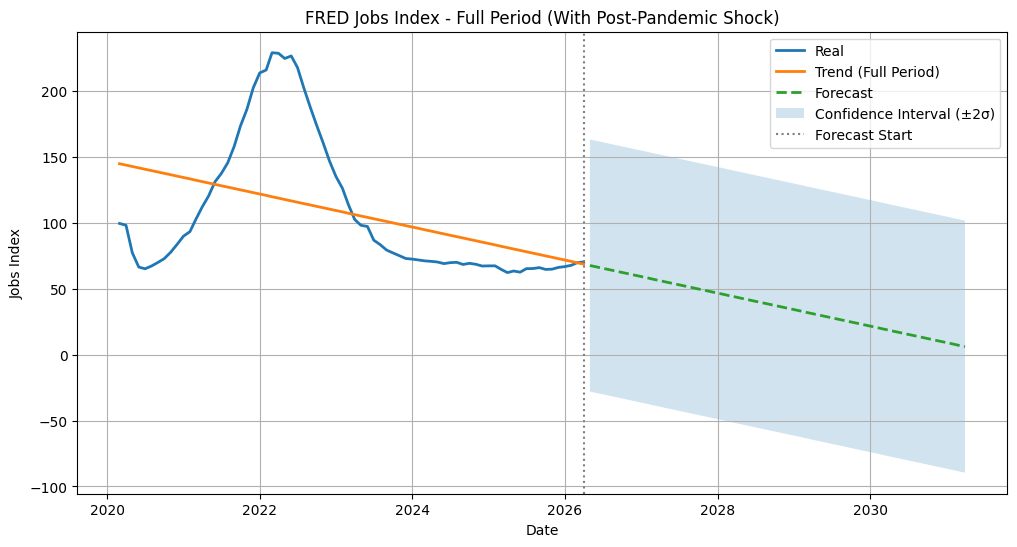

In [140]:
plt.figure(figsize=(12,6))

# Real
plt.plot(
    fred_trend['date'],
    fred_trend['jobs_index'],
    label='Real',
    linewidth=2
)

# Trend
plt.plot(
    fred_trend['date'],
    fred_trend['jobs_index_trend'],
    label='Trend (Full Period)',
    linewidth=2
)

# Forecast
plt.plot(
    fred_forecast['date'],
    fred_forecast['prediction'],
    label='Forecast',
    linestyle='--',
    linewidth=2
)

# Banda
plt.fill_between(
    fred_forecast['date'],
    fred_forecast['lower'],
    fred_forecast['upper'],
    alpha=0.2,
    label='Confidence Interval (±2σ)'
)

# Separador
plt.axvline(
    x=fred_trend['date'].iloc[-1],
    linestyle=':',
    color='gray',
    label='Forecast Start'
)

plt.title('FRED Jobs Index - Full Period (With Post-Pandemic Shock)')
plt.xlabel('Date')
plt.ylabel('Jobs Index')

plt.legend()
plt.grid(True)

plt.show()

O intervalo de confiança do modelo apresenta amplitude excessiva, indicando alta variabilidade nos resíduos. A análise da série histórica revela um comportamento atípico entre 2020 e 2022: forte crescimento seguido de queda abrupta, coincidente com a pandemia de COVID-19. Nesse período, a demanda por profissionais de tecnologia foi artificialmente inflada pela migração massiva ao trabalho remoto, um comportamento que não reflete o regime estrutural atual do mercado.

Como a regressão linear pressupõe padrão consistente ao longo do tempo, a inclusão desse choque distorce a estimativa da tendência e eleva o erro do modelo significativamente.

Portanto, a análise será restrita ao período a partir de janeiro de 2023, que apresenta comportamento mais estável e coincide com a consolidação das ferramentas de IA generativa (ex: ChatGPT), tornando a análise mais representativa do impacto atual dessas tecnologias no mercado de trabalho.

In [141]:
fred_df_filtered = fred_df[fred_df['date'] >= '2023-01-01']

# aplicação das funções auxiliares
fred_trend, model_fred = trend(fred_df_filtered, 'date', 'jobs_index')
fred_forecast = forecast(fred_df_filtered, model_fred, 'date', periods_ahead=60) # 5 anos

# residual
fred_trend['residual'] = fred_trend['jobs_index'] - fred_trend['jobs_index_trend']
std_dev_fred = fred_trend['residual'].std()

# desvio padrão
fred_forecast['upper'] = fred_forecast['prediction'] + 2 * std_dev_fred
fred_forecast['lower'] = fred_forecast['prediction'] - 2 * std_dev_fred

fred_trend.to_csv('output/fred_trend.csv', index=False)
fred_forecast.to_csv('output/fred_forecast.csv', index=False)

O gráfico abaixo repete a análise com o modelo restrito ao período pós-2023. O intervalo de confiança resultante é significativamente mais estreito, confirmando que a exclusão do período pandêmico melhora a estabilidade do modelo.

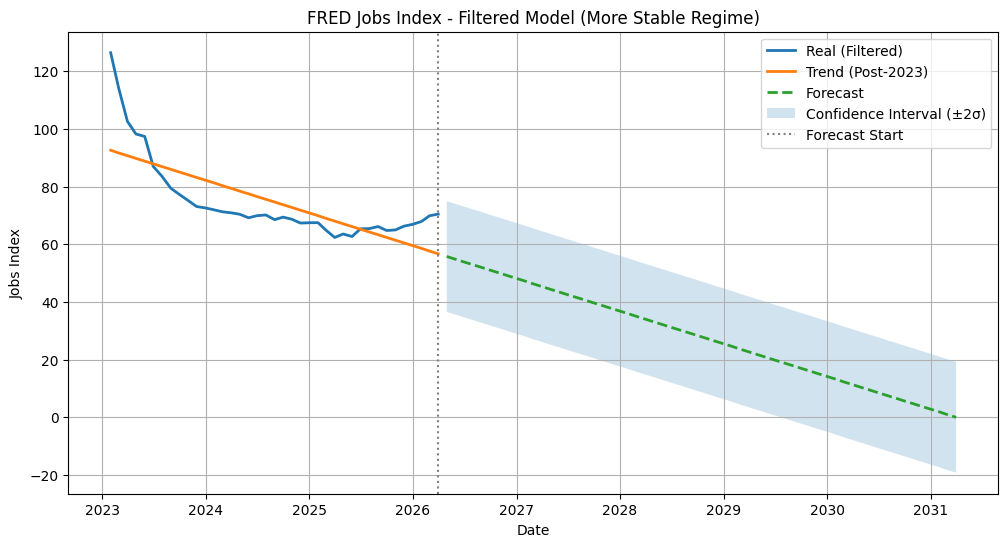

In [142]:
plt.figure(figsize=(12,6))

# Real
plt.plot(
    fred_trend['date'],
    fred_trend['jobs_index'],
    label='Real (Filtered)',
    linewidth=2
)

# Trend
plt.plot(
    fred_trend['date'],
    fred_trend['jobs_index_trend'],
    label='Trend (Post-2023)',
    linewidth=2
)

# Forecast
plt.plot(
    fred_forecast['date'],
    fred_forecast['prediction'],
    label='Forecast',
    linestyle='--',
    linewidth=2
)

# Banda
plt.fill_between(
    fred_forecast['date'],
    fred_forecast['lower'],
    fred_forecast['upper'],
    alpha=0.2,
    label='Confidence Interval (±2σ)'
)

# Separador
plt.axvline(
    x=fred_trend['date'].iloc[-1],
    linestyle=':',
    color='gray',
    label='Forecast Start'
)

plt.title('FRED Jobs Index - Filtered Model (More Stable Regime)')
plt.xlabel('Date')
plt.ylabel('Jobs Index')

plt.legend()
plt.grid(True)

plt.show()

O modelo filtrado apresenta tendência de queda consistente no índice de vagas para desenvolvedores a partir de 2023, com intervalo de confiança bem mais controlado.

#### Correlação entre AIQ e FRED Jobs Index

Para encerrar a etapa de Analytics, calculamos a correlação de Pearson entre o índice AIQ (desempenho do setor de IA) e o FRED Jobs Index (demanda por desenvolvedores), com o objetivo de verificar se o crescimento do mercado de IA está associado a variações na oferta de vagas.

In [143]:
# Carregar dataframes
aiq_df = pd.read_csv('output/aiq_clean.csv')
aiq_df['date'] = pd.to_datetime(aiq_df['date'])

fred_df = pd.read_csv('output/fred_clean.csv')
fred_df['date'] = pd.to_datetime(fred_df['date'])

# Filtrar pelo mesmo período
aiq_df_filtered = aiq_df[aiq_df['date'] >= '2023-01-01'].copy()
fred_df_filtered = fred_df[fred_df['date'] >= '2023-01-01'].copy()

# Criar chave mensal para ser independente do dia exato do mês.
aiq_df_filtered['year_month'] = aiq_df_filtered['date'].dt.to_period('M')
fred_df_filtered['year_month'] = fred_df_filtered['date'].dt.to_period('M')

# Agrega registros dentro do mesmo mês
fred_monthly = (
    fred_df_filtered
    .groupby('year_month', as_index=False)
    .agg({'jobs_index': 'mean'})
)

aiq_monthly = (
    aiq_df_filtered
    .groupby('year_month', as_index=False)
    .agg({
        'aiq_close': 'mean',
        'aiq_growth': 'mean'
    })
)

# Merge
merged = pd.merge(
    aiq_monthly,
    fred_monthly,
    on='year_month',
    how='inner'
)

# Calcular correlação
corr = merged['aiq_close'].corr(merged['jobs_index'])
print(f'Correlação: {corr:.4f}')

Correlação: -0.6916


O coeficiente de correlação calculado é negativo, indicando que o crescimento do AIQ está associado à queda no FRED Jobs Index no período analisado.

Apesar disso, essa relação não deve ser interpretada como causalidade direta. O resultado é consistente com a coexistência de dois fenômenos simultâneos: a normalização do mercado de trabalho pós-pandemia e o avanço acelerado da inteligência artificial. Enquanto o setor de IA apresenta crescimento consistente, o mercado de desenvolvimento de software passa por um processo de ajuste na demanda, o que pode indicar uma reconfiguração das habilidades exigidas, mais do que uma simples substituição de profissionais.

Dado que a janela de dados pós-2023 ainda é relativamente curta, os resultados devem ser tratados como um indicativo inicial. O acompanhamento contínuo dessa série ao longo dos próximos anos será essencial para determinar se o padrão observado representa uma tendência estrutural ou um ajuste temporário do mercado.

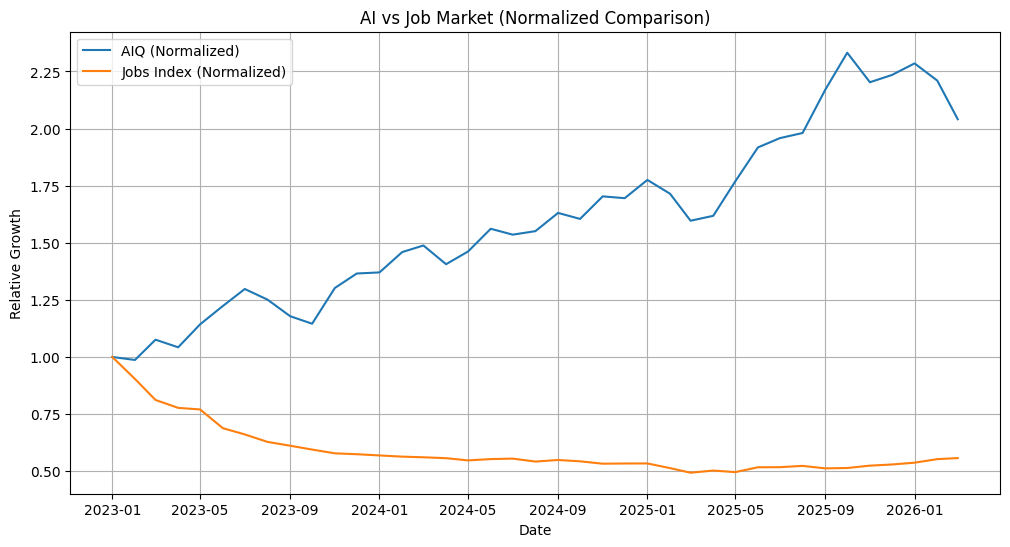

In [144]:
merged['date'] = merged['year_month'].dt.to_timestamp()

merged['aiq_norm'] = merged['aiq_close'] / merged['aiq_close'].iloc[0]
merged['fred_norm'] = merged['jobs_index'] / merged['jobs_index'].iloc[0]

plt.figure(figsize=(12,6))

plt.plot(merged['date'], merged['aiq_norm'], label='AIQ (Normalized)')
plt.plot(merged['date'], merged['fred_norm'], label='Jobs Index (Normalized)')

plt.title('AI vs Job Market (Normalized Comparison)')
plt.xlabel('Date')
plt.ylabel('Relative Growth')

plt.legend()
plt.grid(True)

plt.show()